## 5. Model Preparation

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\krish\ml_ready_data.csv")
df.head()

,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,...,age_group,region_return_risk,high_value_order,price_discount_interaction,profit_pressure,delivery_speed_Standard,delivery_speed_Slow,discount_band_Low,discount_band_Medium,discount_band_High
0,Home,164.08,0.15,1,Credit Card,2023-12-23,2023-12-27,West,0,NaN,...,46-60,0.054495,1,24.6120,4347.2799,True,False,False,True,False
1,Grocery,24.73,0.00,1,Credit Card,2025-04-03,2025-04-09,South,0,NaN,...,36-45,0.056830,0,0.0000,-64.7926,True,False,False,False,False
2,Electronics,175.58,0.05,1,Credit Card,2024-10-08,2024-10-12,North,0,NaN,...,26-35,0.053619,1,8.7790,2241.7920,True,False,True,False,False
3,Electronics,63.67,0.00,1,UPI,2024-09-14,2024-09-20,South,0,NaN,...,18-25,0.056830,1,0.0000,136.2538,True,False,False,False,False
4,Home,16.33,0.15,1,COD,2024-12-21,2024-12-27,East,0,NaN,...,36-45,0.059096,0,2.4495,15.9620,True,False,False,True,False


In [3]:
feature_cols = [
    "price",
    "discount",
    "quantity",
    "shipping_cost",
    "profit_margin",
    "delivery_days",
    "customer_age",

    "category",
    "region",

    "region_return_risk",
    "high_value_order",
    "price_discount_interaction",
    "profit_pressure",

    "delivery_speed_Standard",
    "delivery_speed_Slow",

    "discount_band_Low",
    "discount_band_Medium",
    "discount_band_High"
]

X = df[feature_cols]
y = df["returned"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

## Logistic Regression (Baseline)

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

C:\Users\krish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("Logistic Regression Results")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.5479710144927536
Precision: 0.07138384470882905
Recall: 0.5984251968503937
F1 Score: 0.12755244755244755
ROC-AUC: 0.5996926408129035

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.55      0.69      6519
           1       0.07      0.60      0.13       381

    accuracy                           0.55      6900
   macro avg       0.52      0.57      0.41      6900
weighted avg       0.91      0.55      0.66      6900



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.3).astype(int)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("Random Forest Results")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.21869565217391304
Precision: 0.06129597197898424
Recall: 0.9186351706036745
F1 Score: 0.1149236578558529
ROC-AUC: 0.6088365162362067

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.18      0.30      6519
           1       0.06      0.92      0.11       381

    accuracy                           0.22      6900
   macro avg       0.52      0.55      0.21      6900
weighted avg       0.92      0.22      0.29      6900



In [10]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.31).astype(int)

In [11]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Use XGBoost probabilities (already computed)
thresholds = np.arange(0.05, 0.55, 0.01)

results = []
for t in thresholds:
    preds = (y_prob_xgb >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'recall':    recall_score(y_test, preds, zero_division=0),
        'precision': precision_score(y_test, preds, zero_division=0),
        'f1':        f1_score(y_test, preds, zero_division=0)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold   recall  precision       f1
      0.05 0.984252   0.057746 0.109091
      0.06 0.976378   0.057800 0.109139
      0.07 0.973753   0.058032 0.109536
      0.08 0.973753   0.058554 0.110466
      0.09 0.973753   0.058945 0.111161
      0.10 0.971129   0.059209 0.111614
      0.11 0.971129   0.059601 0.112308
      0.12 0.968504   0.059854 0.112741
      0.13 0.965879   0.060131 0.113213
      0.14 0.963255   0.060392 0.113657
      0.15 0.958005   0.060561 0.113920
      0.16 0.950131   0.060586 0.113908
      0.17 0.944882   0.060759 0.114177
      0.18 0.939633   0.060988 0.114542
      0.19 0.934383   0.061189 0.114857
      0.20 0.926509   0.061179 0.114778
      0.21 0.923885   0.061646 0.115580
      0.22 0.916010   0.061781 0.115755
      0.23 0.908136   0.062063 0.116185
      0.24 0.897638   0.062080 0.116129
      0.25 0.887139   0.062110 0.116091
      0.26 0.881890   0.062535 0.116788
      0.27 0.876640   0.063043 0.117626
      0.28 0.860892   0.062643 0.116788


In [12]:
# Cell 2 — real XGBoost evaluation
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.31).astype(int)

print("===== REAL XGBOOST RESULTS =====")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Not Returned', 'Returned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

===== REAL XGBOOST RESULTS =====
              precision    recall  f1-score   support

Not Returned       0.97      0.29      0.44      6519
    Returned       0.06      0.83      0.12       381

    accuracy                           0.32      6900
   macro avg       0.52      0.56      0.28      6900
weighted avg       0.92      0.32      0.43      6900

ROC-AUC: 0.5954


# 6. Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model to identify the variables that contributed most to predicting product returns.

Among the evaluated machine learning models, Random Forest achieved the highest ROC-AUC score, making it the most suitable model for interpreting feature importance. Although the overall predictive performance was moderate, the importance scores provide valuable insights into which features influenced the model's predictions.

These findings are used to complement the exploratory data analysis and should be interpreted as model-based indicators rather than definitive causal relationships.

In [13]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,profit_margin,0.140114
10,profit_pressure,0.133902
3,shipping_cost,0.132896
0,price,0.125882
6,customer_age,0.085297
9,price_discount_interaction,0.069330
18,category_Grocery,0.061553
17,category_Fashion,0.043146
5,delivery_days,0.034652
7,region_return_risk,0.026812


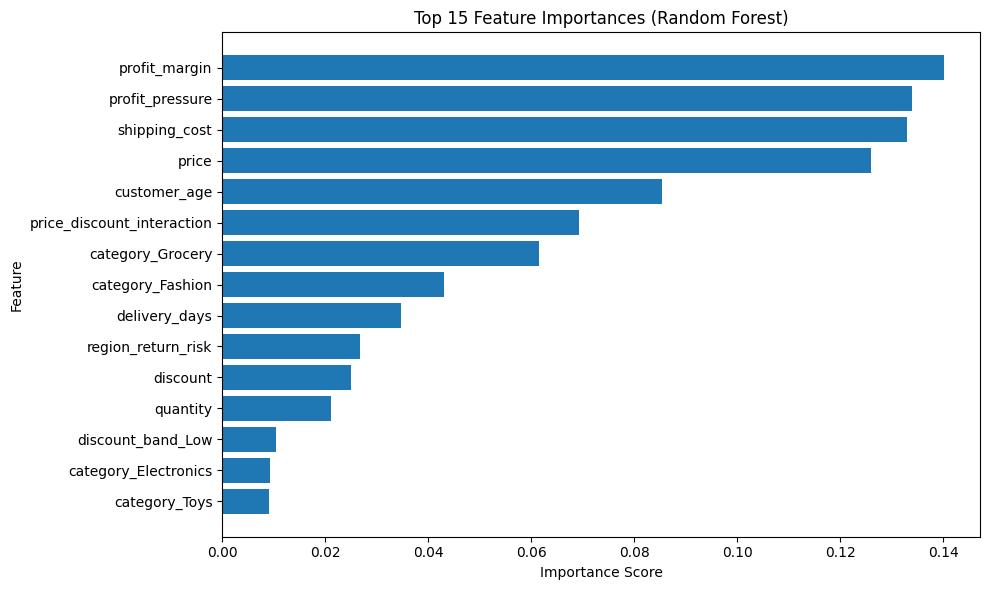

In [14]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances (Random Forest)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [15]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

## Key Findings

- Profit margin was the most influential feature, suggesting that product profitability is closely associated with return behavior.

- Profit pressure and shipping cost also ranked among the top predictors, indicating that operational and financial factors contribute significantly to return risk.

- Product price showed high importance, implying that higher-priced products may exhibit different return patterns than lower-priced products.

- Customer age emerged as an important customer-level feature, suggesting that return behavior varies across age groups.

- The interaction between price and discount was more informative than discount alone, indicating that discounts influence returns differently depending on the product price.

- Product category contributed to prediction, with Grocery and Fashion products having higher importance than other categories.

- Delivery days and regional return risk had moderate influence, suggesting that fulfillment efficiency and geographical patterns also affect return behavior.

## Business Recommendations

- Monitor low-margin products closely, as they are more vulnerable to financial losses when returned.

- Review shipping policies and logistics costs for products with high return risk to reduce operational expenses.

- Optimize pricing and discount strategies instead of offering broad discounts across all products.

- Apply additional quality checks to high-value products before shipment to reduce avoidable returns.

- Develop category-specific return reduction strategies, particularly for Grocery and Fashion products.

- Improve delivery efficiency where possible, as longer delivery times are associated with increased return risk.

# 7. Return Risk Scoring

Rather than classifying orders strictly as returned or not returned, the Random Forest model is used to assign a return probability to every order. This probability is converted into a risk score ranging from 0 to 100, enabling orders to be categorized into Low, Medium, and High risk levels.

This risk scoring approach allows businesses to proactively identify orders that may require additional quality checks, improved packaging, or customer support before fulfillment.

In [17]:
X_all = df.drop(columns=["returned"])

X_all = pd.get_dummies(X_all, drop_first=True)

X_all = X_all.reindex(columns=X_train.columns, fill_value=0)

In [18]:
risk_probability = rf_model.predict_proba(X_all)[:, 1]

In [19]:
risk_df = df.copy()

risk_df["return_probability"] = risk_probability

risk_df["risk_score"] = (risk_probability * 100).round(2)

In [24]:
risk_df["risk_score"].quantile([0.25, 0.50, 0.75, 0.90])

0.25    36.20
0.50    43.72
0.75    49.91
0.90    54.96
Name: risk_score, dtype: float64

In [25]:
risk_df["risk_level"] = pd.cut(
    risk_df["risk_score"],
    bins=[0, 36.20, 49.91, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [26]:
risk_df["risk_level"].value_counts()

risk_level
Medium    17254
Low        8626
High       8620
Name: count, dtype: int64

In [27]:
high_risk_orders = risk_df[risk_df["risk_level"] == "High"]

high_risk_orders.head()

,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,...,price_discount_interaction,profit_pressure,delivery_speed_Standard,delivery_speed_Slow,discount_band_Low,discount_band_Medium,discount_band_High,return_probability,risk_score,risk_level
0,Home,164.08,0.15,1,Credit Card,2023-12-23,2023-12-27,West,0,NaN,...,24.612,4347.2799,True,False,False,True,False,0.511343,51.13,High
6,Electronics,266.50,0.00,1,PayPal,2025-05-20,2025-05-25,East,0,NaN,...,0.000,6097.5200,True,False,False,False,False,0.567040,56.70,High
17,Fashion,16.00,0.00,3,PayPal,2024-09-12,2024-09-17,South,0,NaN,...,0.000,591.3600,True,False,False,False,False,0.505657,50.57,High
19,Fashion,50.52,0.00,1,Credit Card,2024-10-10,2024-10-13,North,1,2024-10-16,...,0.000,579.9696,False,False,False,False,False,0.581369,58.14,High
21,Fashion,39.54,0.00,1,COD,2024-11-14,2024-11-20,North,0,NaN,...,0.000,337.6716,True,False,False,False,False,0.576193,57.62,High


In [28]:
risk_output = risk_df[[
    "category",
    "price",
    "discount",
    "quantity",
    "payment_method",
    "order_date",
    "delivered_date",
    "region",
    "returned",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age",
    "customer_gender",
    "delivery_days",
    "return_probability",
    "risk_score",
    "risk_level"
]]

In [29]:
risk_output.to_csv("return_risk_scoring.csv", index=False)

In [30]:
high_risk_orders = risk_output[
    risk_output["risk_level"] == "High"
]

high_risk_orders.to_csv("high_risk_orders.csv", index=False)

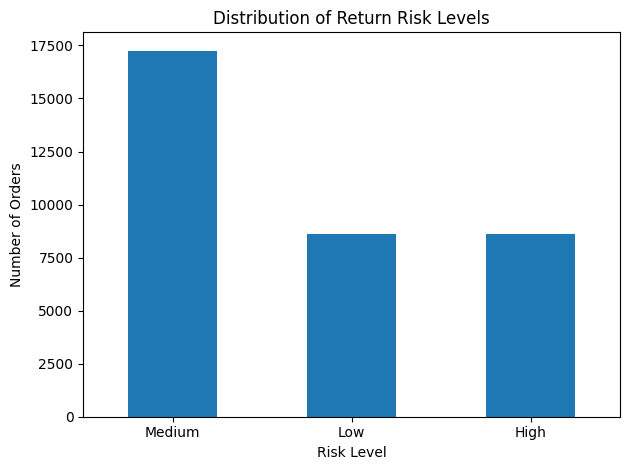

In [31]:
import matplotlib.pyplot as plt

risk_df["risk_level"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Return Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

The Random Forest model was used to assign a return probability to every order, which was converted into a return risk score ranging from 0 to 100. Since the model's predicted probabilities did not naturally exceed 70%, fixed risk thresholds resulted in no High-Risk orders. Therefore, the risk levels were calibrated using the 25th and 75th percentiles of the predicted risk score distribution, creating meaningful Low-, Medium-, and High-Risk segments.

The final distribution consisted of approximately 25% High-Risk, 50% Medium-Risk, and 25% Low-Risk orders. These risk scores should not be interpreted as definitive predictions of whether an order will be returned. Instead, they represent the model's assessment of the relative likelihood of return based on historical patterns.

This risk scoring framework enables businesses to prioritize potentially risky orders for proactive interventions such as enhanced quality checks, improved packaging, or targeted customer support. It also provides an actionable output for operational dashboards and decision-making, even though the predictive performance of the model was moderate.